# Logistic Regression

#### Contrary to its name, this is actually a classification algorithm. Is a supervised machine learning algorithm used for binary classification problems. Instead of predicting continuous values, it predicts the probability of given data belonging to a particular class by applying the logistic function (sigmoid), which outputs values between 0 and 1. Best to use in typical binary classification problems like is an email a spam or not.

## Model
#### General formula:
$$
\hat{y}=\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
z=\omega^Tx+b
$$

#### Where:
#### $\hat{y}\in(0,1) $ - predicted value
#### $x$ - features vector
#### $\omega$ - weights vector
#### $b$ - bias

## Target (loss function)
#### Minimalizing $\textbf{binary cross-entropy}$ function:

$$
J(\omega,b)=-\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log{(\hat{y}^{(i)})}+(1-y^{(i)})\log{(1-\hat{y}^{(i)})}]
$$

#### It penalizes wrong and too certain predictions.

## Dataset

#### Student study hours from Kaggle has been used as a dataset. It has correlation between study hours and scores gained on exam. Student usually passes the exam when he/she has at least 51 points, so data are being tuned in this notebook to pass/fail for logistic regression algorithm to handle.

#### https://www.kaggle.com/datasets/himanshunakrani/student-study-hours

## 1. Import necessary libraries

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Load and visualize dataset

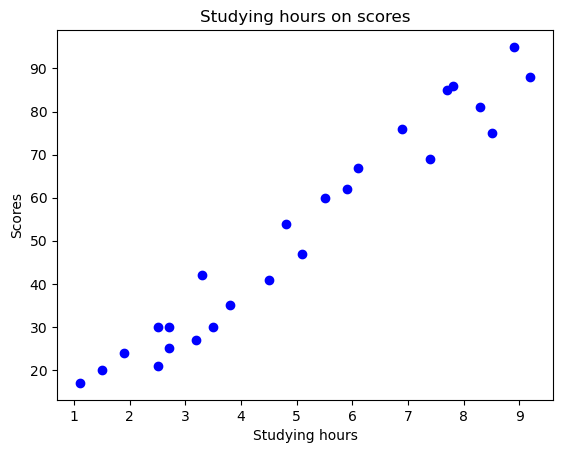

In [40]:
df = pd.read_csv('data/score.csv')
plt.scatter(df['Hours'], df['Scores'], color='blue')
plt.title('Studying hours on scores')
plt.xlabel('Studying hours')
plt.ylabel('Scores')
plt.show()

## 3. Split the data into training and testing sets and visualize exam results

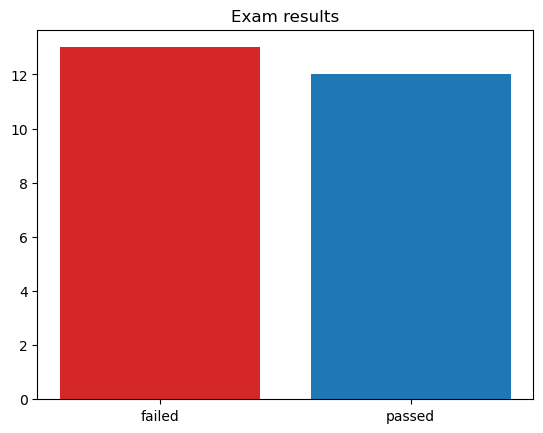

In [41]:
X = df['Hours'].to_numpy().reshape(-1, 1)
y = df['Scores'].apply(lambda x: 1 if x > 50 else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = ['failed', 'passed']
counts = [y.value_counts()[0], y.value_counts()[1]]
bar_colors = ['tab:red', 'tab:blue']

plt.bar(results, counts, color=bar_colors)
plt.title('Exam results')
plt.show()

## 4. Initialize and train the model

In [42]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## 5. Make predictions and evaluate the model

In [43]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print('Accuracy:', accuracy)
print('Confusion matrix:', conf_matrix)

Accuracy: 1.0
Confusion matrix: [[2 0]
 [0 3]]


## 6. Visualize predictions

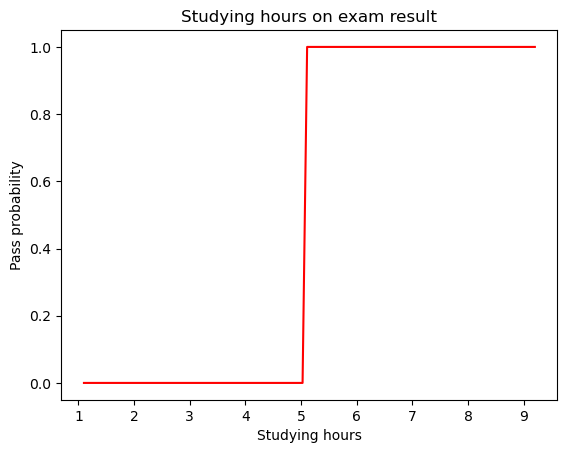

In [44]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', label='logistic regression')
plt.title('Studying hours on exam result')
plt.xlabel('Studying hours')
plt.ylabel('Pass probability')
plt.show()